# Exercise 6.4

### Importing libraries and data

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import os
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [6]:
%matplotlib inline

In [8]:
path = r'C:\Users\jeffr\Documents\Medical Costs Analysis'

In [10]:
df = pd.read_csv(os.path.join(path, '02 Data', 'Prepared Data', 'insurance.csv'), index_col = False)

### Data cleaning

In [13]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [15]:
df.head(20)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,West,16884.92400
1,18,male,33.770,1,no,South,1725.55230
2,28,male,33.000,3,no,South,4449.46200
3,33,male,22.705,0,no,Midwest,21984.47061
4,32,male,28.880,0,no,Midwest,3866.85520
5,31,female,25.740,0,no,South,3756.62160
6,46,female,33.440,1,no,South,8240.58960
7,37,female,27.740,3,no,Midwest,7281.50560
8,37,male,29.830,2,no,Northeast,6406.41070
9,60,female,25.840,0,no,Midwest,28923.13692


In [17]:
df.shape

(1337, 7)

In [21]:
# check for missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [23]:
# check for duplicates
dups = df.duplicated()

In [25]:
dups.shape

(1337,)

C:\Users\jeffr\AppData\Local\Temp\ipykernel_23064\3701429068.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['charges'], bins=25)


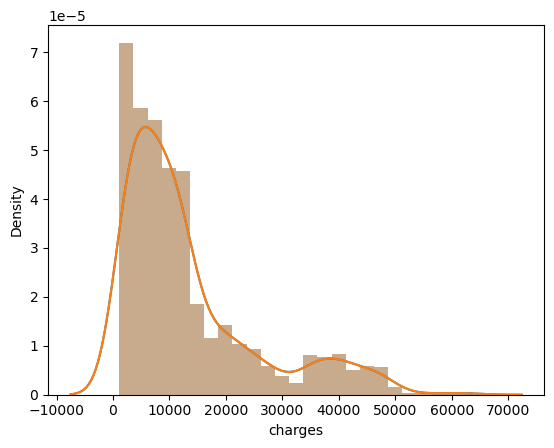

In [29]:
# check for extreme values
sns.distplot(df['charges'], bins=25)
plt.show()

In [31]:
df['charges'].mean()

13279.121486655948

In [33]:
df['charges'].median()

9386.1613

In [35]:
df['charges'].max()

63770.42801

### Data prep for regression analysis

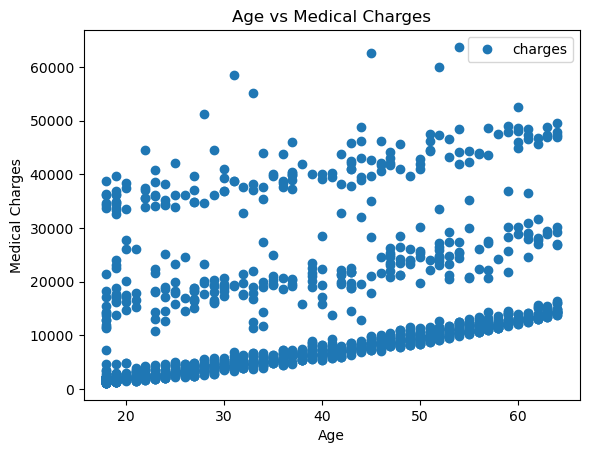

In [38]:
# creating scatterplot
df.plot(x = 'age', y='charges', style='o')
plt.title('Age vs Medical Charges')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.show()

In [40]:
# Reshape the variables into Numpy arrays and put them into separate objects.
x = df['age'].values.reshape(-1,1)
y = df['charges'].values.reshape(-1,1)

In [42]:
x

array([[19],
       [18],
       [28],
       ...,
       [18],
       [21],
       [61]], dtype=int64)

In [44]:
y

array([[16884.924 ],
       [ 1725.5523],
       [ 4449.462 ],
       ...,
       [ 1629.8335],
       [ 2007.945 ],
       [29141.3603]])

In [48]:
# Split data into a training set and test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

### Regression analysis

In [53]:
# Creating a regression object
regression = LinearRegression()

In [55]:
# Fit the regression object onto the training set
regression.fit(x_train, y_train)

LinearRegression()

In [57]:
# Predict the values of y using x
y_predicted = regression.predict(x_test)

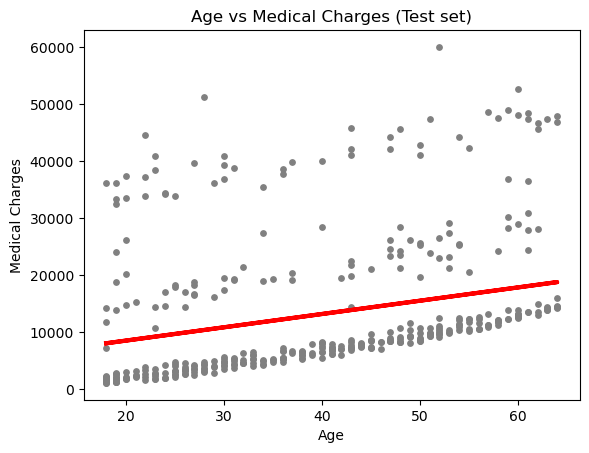

In [59]:
# Creating a plot that shows the regression line from the model on the test set
plot_test = plt
plot_test.scatter(x_test, y_test, color='gray', s = 15)
plot_test.plot(x_test, y_predicted, color='red', linewidth = 3)
plot_test.title('Age vs Medical Charges (Test set)')
plot_test.xlabel('Age')
plot_test.ylabel('Medical Charges')
plot_test.show()

In [61]:
# Create objects that contain the model summary statistics
rmse = mean_squared_error(y_test, y_predicted)
r2 = r2_score(y_test, y_predicted)

In [63]:
# Print model summary statistics
print('Slope:' ,regression.coef_)
print('Mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [[233.02389044]]
Mean squared error:  146173303.34737504
R2 score:  0.10739068301367438


In [65]:
y_predicted

array([[ 8086.24297948],
       [14843.9358021 ],
       [15309.98358297],
       [ 8319.26686991],
       [15776.03136384],
       [ 9950.43410296],
       [ 8086.24297948],
       [ 8319.26686991],
       [ 8319.26686991],
       [17407.19859688],
       [15076.95969253],
       [ 9950.43410296],
       [18572.31804906],
       [14144.86413079],
       [12280.67300731],
       [ 9251.36243165],
       [12280.67300731],
       [ 9950.43410296],
       [12746.72078818],
       [18805.34193949],
       [ 8086.24297948],
       [17873.24637775],
       [ 8319.26686991],
       [ 9018.33854122],
       [ 9018.33854122],
       [11348.57744557],
       [10416.48188383],
       [15309.98358297],
       [11115.55355513],
       [ 8552.29076035],
       [13212.76856905],
       [15776.03136384],
       [16941.15081601],
       [16708.12692558],
       [ 9484.38632209],
       [18106.27026819],
       [14610.91191166],
       [10416.48188383],
       [14843.9358021 ],
       [ 8552.29076035],


In [69]:
# Creating dataframe comparing the actual andpredicted values of y
data = pd.DataFrame({'Actual': y_test.flatten(), 'Predicted': y_predicted.flatten()})
data.head(30)

,Actual,Predicted
0,1633.96180,8086.242979
1,8547.69130,14843.935802
2,9290.13950,15309.983583
3,32548.34050,8319.266870
4,9644.25250,15776.031364
5,2680.94930,9950.434103
6,2198.18985,8086.242979
7,1241.56500,8319.266870
8,2710.82855,8319.266870
9,12235.83920,17407.198597


#### Compare how the regression fits the training set

In [72]:
y_predicted_train = regression.predict(x_train)

In [74]:
rmse = mean_squared_error(y_train, y_predicted_train)
r2 = r2_score(y_train, y_predicted_train)

In [76]:
print('Slope:' ,regression.coef_)
print('Mean squared error: ', rmse)
print('R2 score: ', r2)

Slope: [[233.02389044]]
Mean squared error:  128318059.75747488
R2 score:  0.07682646420531714


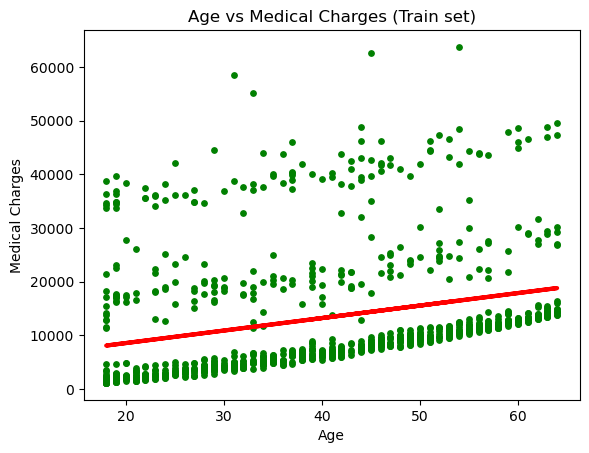

In [79]:
# Visualizing the training set results
plot_test = plt
plot_test.scatter(x_train, y_train, color='green', s = 15)
plot_test.plot(x_train, y_predicted_train, color='red', linewidth =3)
plot_test.title('Age vs Medical Charges (Train set)')
plot_test.xlabel('Age')
plot_test.ylabel('Medical Charges')
plot_test.show()

In [84]:
data2 = pd.DataFrame({'Actual': y_train.flatten(), 'Predicted': y_predicted_train.flatten()})
data2.head(30)

,Actual,Predicted
0,5649.71500,12979.744679
1,11363.28320,17407.198597
2,7419.47790,14144.864131
3,5261.46945,11581.601336
4,2203.47185,8086.242979
5,3268.84665,10416.481884
6,13143.86485,18106.270268
7,6781.35420,13445.792459
8,10601.63225,16708.126926
9,8556.90700,14843.935802


### Although groupings of the data does follow the slope of the regression line, this model is very poor for predicting medical charges by age.  Not only is the R2 score on the Test set was very poor at 11% and the dataframe comparing actual vs predicted reflects that as there are great differences between the two.  The R2 score using the Training set was much higher at 77% however there was just as much disparity between the actual and predicted.

In [87]:
print(float(' '))

ValueError: could not convert string to float: ' '